# 1. 멋진 단어사전 만들기
이번 코스에서 우리가 배울 것이 바로 문장을 조각내는 방법입니다. 어떤 문장을 일정한 기준을 갖는 단어로 쪼개는 것, 그것은 곧 퍼즐 조각을 나누는 것과 같죠! 지나치게 잘게 쪼개면 넓은 그림을 담을 수 없어 다시 맞추기 어려울 것이고, 너무 크게 쪼갰다간 퍼즐이 너무 쉬워지고 말 겁니다.

이번 코스에선 문장 데이터를 직접 토큰화하며 어떤 방법이 가장 적합한 단어 조각을 만들어 내는지 실습해보도록 하겠습니다.

## 학습 내용
2. 데이터 다운로드 및 분석
학습 환경을 구성하고 필요한 데이터를 다운로드합니다.
3. 공백 기반 토큰화
공백 기반 토큰화를 실습하고 문제점을 확인합니다.
4. 형태소 기반 토큰화
KoNLPy, 그중에서도 가장 성능이 준수한 MeCab클래스를 활용해 실습합니다.
## 학습 목표
학습 환경을 구성하고 필요한 데이터를 다운로드할 수 있습니다.
공백 기반 토큰화를 실습하고 문제점을 확인할 수 있습니다.
형태소 기반 토큰화를 실습하고 사용할 수 있습니다.

In [19]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 48.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]
Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 7.44 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/home/jovyan/work/projects/AIFFEL_quest_rs/Exploration/Ex06/Mecab-ko-for-Google-Colab
install_mecab-ko_on_colab_light_220429.sh: line 4: cd: /content: No such file or directory
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-06-15 04:38:54--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mec

In [1]:
from konlpy.tag import Mecab

mecab = Mecab()
print(mecab.morphs('자연어처리가너무재밌어서밥먹는것도가끔까먹어요'))

['자연어', '처리', '가', '너무', '재밌', '어서', '밥', '먹', '는', '것', '도', '가끔', '까먹', '어요']


# 2. 데이터 다운로드 및 분석  

먼저 프로젝트에 사용될 라이브러리를 import 합니다.

In [2]:
import os

import matplotlib.pyplot as plt
import torch
import numpy as np

%matplotlib inline

In [3]:
# !wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
# !tar -xzvf korean-english-park.train.tar.gz

In [4]:
import os
path_to_file = "korean-english-park.train.ko"

with open(path_to_file, "r") as f:
    raw = f.read().splitlines()

print("Data Size:", len(raw))

print("Example:")
for sen in raw[0:100][::20]: print(">>", sen)

Data Size: 94123
Example:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.


내려받은 데이터는 한국어의 형태소 분석과 품사 태깅, 기계 번역 연구를 위해 공개된 데이터입니다. 이번에 사용할 데이터는 한국어-영어 병렬을 이루는 말뭉치 중 한국어 부분으로, 전체 병렬 말뭉치는 후에 번역기를 만들며 사용할 예정입니다!

혹시 다른 종류의 데이터가 궁금하시다면 아래 Github를 방문해보세요!

jungyeul/korean-parallel-corpora
자, 데이터가 우리 손으로 들어왔으니 씹고 뜯고 맛볼 차례입니다! 멋진 시각화를 동반한 통계적 분석...까지는 하지 않고요. 최소한의 분석으로 데이터가 얼마나 있고, 어떻게 생겼는지 정도를 직접 확인해 봅시다.

문장은 위에서 확인한 것처럼 94123개가 포함되어 있습니다. 우리는 각 문장이 어느 정도의 길이를 가지는지 확인해보겠습니다! 이 과정을 거치면 지나치게 긴 데이터를 삭제하거나 (연산량을 감소시켜 학습 속도가 빨라집니다!) 지나치게 짧은 데이터를 검증 (무조건 필요가 없지는 않습니다, 단어 ↔ 단어 라면 번역을 학습할 수 있겠죠!) 할 수 있습니다. 즉, 데이터를 얼마나 사용할지 타협점을 정의할 수 있습니다.

아래 소스는 문장의 최단 길이, 최장 길이, 평균 길이를 구한 후 문장 길이 분포를 막대그래프로 표현해 주는 소스입니다. raw 변수는 앞서 다운로드받은 데이터가 담긴 변수입니다!

문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 60


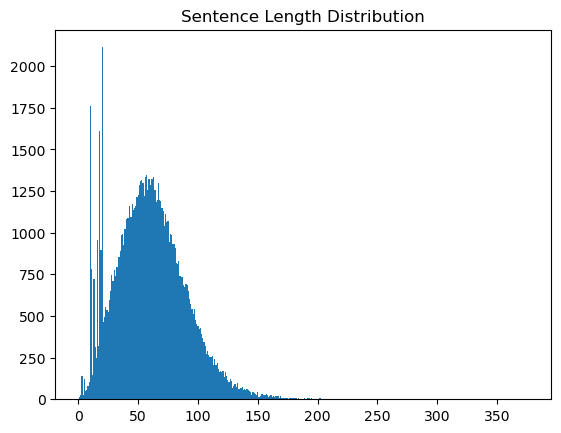

In [5]:
min_len = 999
max_len = 0
sum_len = 0

for sen in raw:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(raw))

sentence_length = np.zeros((max_len), dtype=int)

for sen in raw:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

최단 길이 1, 최장 길이 377... 그리고 제법 그럴듯한 막대그래프가 나왔습니다만, 이 결과를 확인하고 드는 생각은 아래와 크게 다르지 않으실 거예요..!

1) 길이 1 짜리 문장은 도대체 어떻게 생겨먹었지?

2) 앞에 치솟는 임의의 구간은 뭐지? 유의미한 데이터가 담겨있는 부분인가?

3) 어디서부터 어디까지 잘라서 쓰지?

궁금증을 하나하나 해결해 봅시다! 대체 길이가 1인 문장은 뭘까요?

In [6]:
def check_sentence_with_length(raw, length):
    count = 0

    for sen in raw:
        if len(sen) == length:
            print(sen)
            count += 1
            if count > 100: return

check_sentence_with_length(raw, 1)

’


오잉? 하마터면 완전 노이즈인 데이터를 그대로 사용할 뻔했습니다! 왠지 길이별로 확인할 일이 많을 것 같아 함수를 미리 정의해두었는데, 이를 이용해 확인이 필요해 보이는 문장은 모두 확인해보죠.

In [7]:
for idx, _sum in enumerate(sentence_length):
    # 문장의 수가 1500을 초과하는 문장 길이를 추출합니다.
    if _sum > 1500:
        print("Outlier Index:", idx+1)

Outlier Index: 11
Outlier Index: 19
Outlier Index: 21


In [8]:
check_sentence_with_length(raw, 11)

라고 조던이 말했다.
- 모르고 있습니다.
- 네, 보이는군요.
디즈니사만이 아니다.
큰 파티는 아니지요.
의자는 비어 있었다.
이 일은 계속됩니다.
나는 크게 실망했다.
그 이유는 간단하다.
이력서와 자기 소개서
시대가 변하고 있다.
는 돌발질문을 했다.
9. 몇 분간의 명상
하와이, 빅 아일랜드
키스를 잘 하는 방법
키스를 잘 하는 방법
스피어스가 뚱뚱한가?
산 위를 나는 느낌.
세 시간쯤 걸었을까?
(아직 읽고있습니까?
처음에는 장난이었다.
우리는 운이 좋았다.
아기가 숨을 멈출 때
건물 전체 무너져내려
그녀의 아름다운 눈.
대답은 다음과 같다.
"사과할 것이 없다.
폭탄테러가 공포 유발
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1

위에서 찾은 outlier index 중 하나인, 길이가 11인 문장들은 어떤 것들이 있는지 확인해봅시다.

In [9]:
check_sentence_with_length(raw, 11)

라고 조던이 말했다.
- 모르고 있습니다.
- 네, 보이는군요.
디즈니사만이 아니다.
큰 파티는 아니지요.
의자는 비어 있었다.
이 일은 계속됩니다.
나는 크게 실망했다.
그 이유는 간단하다.
이력서와 자기 소개서
시대가 변하고 있다.
는 돌발질문을 했다.
9. 몇 분간의 명상
하와이, 빅 아일랜드
키스를 잘 하는 방법
키스를 잘 하는 방법
스피어스가 뚱뚱한가?
산 위를 나는 느낌.
세 시간쯤 걸었을까?
(아직 읽고있습니까?
처음에는 장난이었다.
우리는 운이 좋았다.
아기가 숨을 멈출 때
건물 전체 무너져내려
그녀의 아름다운 눈.
대답은 다음과 같다.
"사과할 것이 없다.
폭탄테러가 공포 유발
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1

이런... 심지어 중복에 대한 처리도 제대로 하지 않았었네요. 중복 제거는 Python의 기본 자료형 set을 활용할 겁니다. set은 집합을 정의하는 자료형인데, 중복을 허용하지 않아 변환 과정에서 자동으로 중복된 요소를 제거해 주거든요! 대신 list의 순서가 뒤죽박죽될 수 있으니, 만약 번역 데이터처럼 쌍을 이뤄야 하는 경우라면 주의해서 사용하셔야 합니다!

중복을 제거한 후, 앞에서 분포를 확인한 소스를 다시 실행시켜 보겠습니다!

Data Size: 77591
문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 64


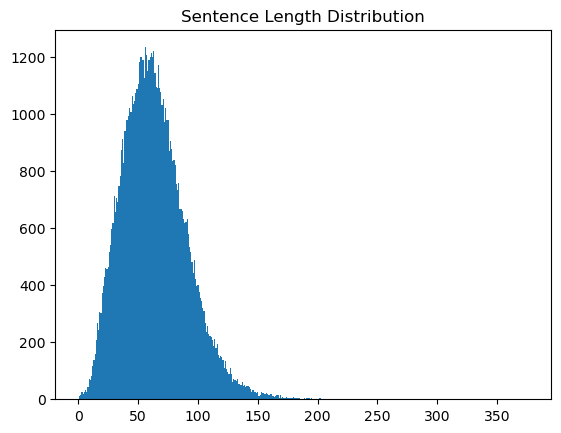

In [10]:
min_len = 999
max_len = 0
sum_len = 0

cleaned_corpus = list(set(raw))  # set를 사용해서 중복을 제거합니다.
print("Data Size:", len(cleaned_corpus))

for sen in cleaned_corpus:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(cleaned_corpus))

sentence_length = np.zeros((max_len), dtype=int)

for sen in cleaned_corpus:   # 중복이 제거된 코퍼스 기준
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

이제서야 깔끔한 데이터를 얻은 느낌이 드네요. 데이터의 개수도 17000개 가량 줄어 77591개가 되었습니다.

마지막으로 **'모든 데이터를 다 사용할 것이냐' 가 문제인데, 후에 미니 배치를 만들 것을 생각하면 모든 데이터를 다 사용하는 것은 연산 측면에서 비효율적입니다. 미니 배치 특성상 각 데이터의 크기가 모두 동일해야 하기 때문에 가장 긴 데이터를 기준으로 Padding 처리를 해야 합니다. 위의 데이터에서 만약 길이가 100인 문장까지만 사용한다면 데이터는 [ (77591 - 길이 100 초과 문장 수) x 100 ] 의 형태를 갖겠지만 모두 사용할 경우 [ 77591 x 377 ] 로 전자보다 최소 3.7배 큰 메모리를 차지합니다. 학습 시간도 그만큼 더 오래 걸리고요.**

길이별로 정렬하여 미니 배치를 구성해 Padding을 최소화하는 방법도 있지만 이는 데이터를 섞는 데 편향성이 생길 수 있으므로 지양해야 합니다. 여기서는 길이 150 이상의 데이터를 제거하고 사용하도록 할게요!

그리고 앞서 확인한 것처럼 너무 짧은 데이터는 오히려 노이즈로 작용할 수 있습니다. 따라서 길이가 10 미만인 데이터도 제거하도록 하죠! 최종 데이터 분포도 함께 확인해봅시다.

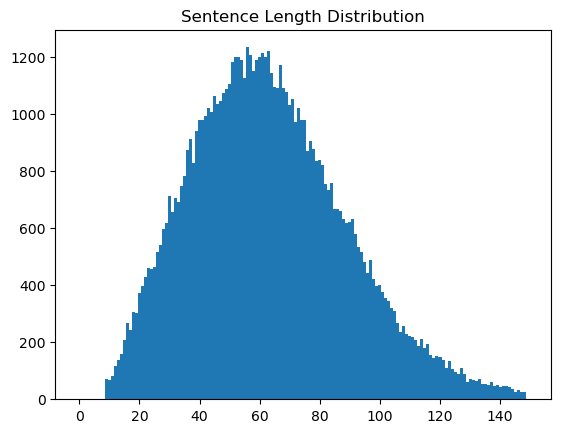

In [11]:
max_len = 150
min_len = 10

# 길이 조건에 맞는 문장만 선택합니다.
filtered_corpus = [s for s in cleaned_corpus if (len(s) < max_len) & (len(s) >= min_len)]

# 분포도를 다시 그려봅니다.
sentence_length = np.zeros((max_len), dtype=int)

for sen in filtered_corpus:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

# 3. 공백 기반 토큰화
배운 순서대로, 먼저 공백 기반 토큰화를 진행해 봅시다!

이전 스텝에서 얻은 정제된 데이터 filtered_corpus를 공백 기반으로 토큰화하여 리스트 split_corpus에 저장한 후, 아래 tokenize() 함수를 사용해 단어 사전과 Tensor 데이터를 얻으세요! 그리고 단어 사전의 크기를 확인하세요!

In [12]:
import torch
from torch.nn.utils.rnn import pad_sequence

class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters

    def fit_on_texts(self, corpus):
        # 각 문장을 토큰화하여 단어 사전을 생성 (인덱스는 1부터 시작)
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1
        # 역방향 사전 생성
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            # 존재하지 않는 단어는 0으로 처리
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            # tensor인 경우 리스트로 변환
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            # 패딩 토큰(0)은 제외하고 디코딩
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

In [13]:
def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    # padding 토큰은 0
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

In [14]:
# 정제된 데이터 filtered_corpus를 공백 기반으로 토큰화하여 저장하는 코드를 직접 작성해 보세요.
split_corpus = []

for kor in filtered_corpus:
    split_corpus.append(kor.split())

In [15]:
len(split_corpus)

76908

In [16]:
split_corpus = []

for kor in filtered_corpus:
    split_corpus.append(kor.split())

정답을 확인해 보셨나요? 이제 공백 기반 토큰화를 진행한 후, 단어 사전의 길이를 확인해봅시다.

In [17]:
split_tensor, split_tokenizer = tokenize(split_corpus)

print("Split Vocab Size:", len(split_tokenizer.index_word))
#아래의 코드로 생성된 단어 사전을 확인해 볼 수 있습니다.

Split Vocab Size: 238305


In [18]:
for idx, word in enumerate(split_tokenizer.word_index):
    print(idx, ":", word)

    if idx > 10: break

0 : 인어상은
1 : 덴마크
2 : 조각가인
3 : 에드바르드
4 : 에릭센이
5 : 덴마크의
6 : 동화작가
7 : 한스
8 : 크리스챤
9 : 안데르센에
10 : 대한
11 : 경의를


동사로 이루어진 단어를 살피면 공백 기반 토큰화의 문제점을 확인할 수 있습니다. 1번 단어인 밝혔다. 는 밝히다 , 밝다 등과 유사한 의미를 지니고 있음에도 전혀 다른 단어로 분류되겠죠? 이 때문에 공백 기반 토큰화는 불필요하게 큰 단어 사전을 가지게 되며 이는 연산량 증가로 이어집니다.

만일 밝 + 혔다 라고 토큰화했다면 어땠을까요? 밝 + 히다, 밝 + 다 같은 구절이 등장했을 때, 공통된 어절인 밝 은 하나로 묶여 학습 중에 의미를 파악하기가 수월해지겠죠? 동시에 단어 사전도 효율적으로 축소될 것입니다. 이를 위해 형태소 분석기가 존재합니다!

# 4. 형태소 기반 토큰화
한국어 형태소 분석기는 대표적으로 Khaiii와 KoNLPy가 사용됩니다. 이번 코스에서는 KoNLPy, 그중에서도 가장 성능이 준수한 MeCab클래스를 활용해 실습하도록 하겠습니다!

앞서 작성했던 코드를 활용해 MeCab 기반으로 생성된 단어 사전과 Tensor 데이터를 얻어 봅시다!

In [19]:
# 위에서 사용한 코드를 활용해 MeCab 단어 사전을 만들어보세요.
# Hint : mecab.morphs()를 사용해서 형태소분석을 합니다.
def mecab_split(sentence):
    return mecab.morphs(sentence)

mecab_corpus = []

for kor in filtered_corpus:
    mecab_corpus.append(mecab_split(kor))

In [20]:
def mecab_split(sentence):
    return mecab.morphs(sentence)

mecab_corpus = []

for kor in filtered_corpus:
    mecab_corpus.append(mecab_split(kor))

In [21]:
mecab_tensor, mecab_tokenizer = tokenize(mecab_corpus)

print("MeCab Vocab Size:", len(mecab_tokenizer.index_word))

MeCab Vocab Size: 53642


In [22]:
mecab_tensor, mecab_tokenizer = tokenize(mecab_corpus)

print("MeCab Vocab Size:", len(mecab_tokenizer.index_word))

MeCab Vocab Size: 53642


앞서 실습했던 공백 기반 단어 사전에 비해 단어 수가 현저히 줄어든 것을 확인하셨을 겁니다. 이는 곧 연산량의 감소로 이어져 더 빠른 학습을 가능케 하고, 심지어 모델이 튜닝해야 하는 매개변수(Parameter) 수가 줄어들어 학습도 더 잘 된답니다! 적어도 한국어를 처리할 때는 공백 기반 토큰화를 절대 지양하셔야 해요!

자주 사용되는 SentencePiece같은 Subword 기반 토큰화보다 형태소 분석기가 좋은 성능을 내는 사례들이 종종 있는데요, ETRI에서 발표한 한국어 BERT 모델인 KorBERT가 대표적인 사례 중 하나입니다. 아래 웹페이지를 방문하면 모델의 자세한 구조뿐 아니라 KorBERT 모델을 5가지 자연어 처리 태스크를 기준으로 평가했던 흥미로운 결과까지 살펴보실 수 있습니다!

공공 인공지능 오픈 API·DATA 서비스 포털
자연어 처리에서 토크나이저가 성능에 미치는 영향도가 크다는 것은 주지의 사실입니다만, 위 링크에서 발표된 평가 결과를 살펴볼 때 몇 가지 생각해 볼 만한 지점이 있습니다.

아래 질문들에 대해 스스로 생각해 보고 본인의 생각을 정리해서 답변해 보시기 바랍니다. 사실 정답이 있는 문제는 아니기 때문입니다.

 구글의 Word Piece 기반 한국어 언어모델이 엑소브레인의 Word Piece 기반 한국어 언어모델보다 전체적으로 성능이 크게 떨어지는 것은 어떤 의미일까요? 여기서 유의해야 할 것은 언어모델(BERT)을 훈련시킨 원리는 동일하며, 토크나이저가 구성된 원리도 Word Piece 기반으로 동일하다는 점입니다.  
 "아무리 훌륭한 딥러닝 알고리즘(BERT)과 효율적인 토크나이저 기술(WordPiece)을 사용하더라도, 해당 언어의 문화와 특성을 반영한 '양질의 데이터'와 '언어 맞춤형 단어 사전 구축'이 받쳐주지 않으면 언어모델은 제 성능을 낼 수 없다."

 엑소브레인의 BERT에 두 가지 버전이 있는데, 이 중 한국어 전용 형태소분석기 토크나이저를 사용한 버전이 WordPiece 모델 토크나이저를 사용한 버전보다 대체로 성능이 좋다는 것의 시사점은 무엇일까요?  
 아무리 뛰어난 인공지능 알고리즘(BERT)이라도 수학적·통계적 계산(WordPiece)에만 의존하는 것보다, 해당 언어의 언어학적 특성(형태소 분석)을 결합했을 때 비로소 최적의 성능을 발휘할 수 있다는 점을 보여주는 대표적인 사례입니다.


Q. 정교한 형태소분석기를 활용한 모델의 성능이 더 좋을 수 있음에도 불구하고 현장에서 SentencePiece 같은 Subword 기반 토크나이저가 더욱 각광받는 이유는 무엇일까요?  
 성능 면에서는 형태소 분석기가 한국어 구조를 더 정밀하게 짚어낼 수 있지만, 현장(배포 및 서비스 운영 환경)에서는 어떤 텍스트가 들어와도 에러 없이 처리하는 안정성(OOV 해결), 빠른 속도, 편리한 시스템 구축 및 다국어 확장성이라는 압도적인 서빙(Serving) 이점 때문에 SentencePiece 같은 Subword 기반 방식을 표준으로 사용하고 있습니다.



 지금까지 문장을 Tensor로 Encoding하는 과정을 배웠는데요. 

후에 모델이 생성한 Tensor를 문장으로 Decoding하는 과정도 필요하겠죠?

tokenizer.sequences_to_texts() 함수를 사용하여 Decoding
tokenizer.index_word 를 사용하여 Decoding
두 가지 방법으로 mecab_tensor[100] 을 원문으로 되돌려 보세요!

(여기서 띄어쓰기는 고려하지 않습니다!)

In [23]:
# Case 1 : tokenizer.sequences_to_texts()

texts = mecab_tokenizer.sequences_to_texts([mecab_tensor[100]])
print(texts[0])

['문제', '의', '동영상', '이', '제거', '됐', '는데', '도', '불구', '하', '고', '인터넷', '사용', '자', '들', '은', '다음', '날', '에', '도', '계속', '다른', '포털', '사이트', '에', '‘', '야후', '동영상', '’', '을', '검색', '했', '다', '.']


In [24]:
# Case 2 : tokenizer.index_word

sentence = ""

for w in mecab_tensor[100]:
    w = int(w)
    if w == 0: continue
    sentence += mecab_tokenizer.index_word[w] + " "

print(sentence)

문제 의 동영상 이 제거 됐 는데 도 불구 하 고 인터넷 사용 자 들 은 다음 날 에 도 계속 다른 포털 사이트 에 ‘ 야후 동영상 ’ 을 검색 했 다 . 


# 프로젝트: SentencePiece 사용하기
라이브러리 버전을 확인해 봅니다
사용할 라이브러리 버전을 둘러봅시다.

In [25]:
import torch
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import konlpy

print(torch.__version__)
print(np.__version__)
print(matplotlib.__version__)
print(konlpy.__version__)

2.7.1+cu118
2.2.6
3.10.3
0.6.0


# Step 1. SentencePiece 설치하기
SentencePiece는 Google에서 제공하는 오픈소스 기반 Sentence Tokenizer/Detokenizer 로서, BPE와 unigram 2가지 subword 토크나이징 모델 중 하나를 선택해서 사용할 수 있도록 패키징한 것입니다. 아래 링크의 페이지에서 상세한 내용을 파악할 수 있습니다.

google/sentencepiece
위 페이지의 서두에서도 언급하고 있듯, SentencePiece는 딥러닝 자연어처리 모델의 앞부분에 사용할 목적으로 최적화되어 있는데, 최근 pretrained model들이 거의 대부분 SentencePiece를 tokenizer로 채용하면서 사실상 표준의 역할을 하고 있습니다.

다음과 같이 설치를 진행합니다. SentencePiece는 python에서 쓰라고 만들어진 라이브러리는 아니지만 편리한 파이썬 wrapper를 아래와 같이 제공하고 있습니다.

In [26]:
 !pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.8 MB/s eta 0:00:00 0:00:01


# Step 2. SentencePiece 모델 학습
앞서 배운 tokenize() 함수를 기억하나요? 다시 한번 상기시켜드릴게요!

In [27]:
class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters

    def fit_on_texts(self, corpus):
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

위와 같이 Tokenizer에 corpus를 주고 tokenizer.fit_on_texts(corpus)을 하면 토크나이저 내부적으로 단어사전과 토크나이저 기능을 corpus에 맞춤형으로 자동 생성해 주는 것입니다.

그럼 이를 위해서 SentencePiece 모델을 학습하는 과정을 거쳐야 합니다.

In [28]:
import sentencepiece as spm
import os
temp_file = 'korean-english-park.train.ko.temp'

vocab_size = 8000

with open(temp_file, 'w') as f:
    for row in filtered_corpus:   # 이전에 나왔던 정제했던 corpus를 활용해서 진행해야 합니다.
        f.write(str(row) + '\n')

spm.SentencePieceTrainer.Train(
    '--input={} --model_prefix=korean_spm --vocab_size={}'.format(temp_file, vocab_size)    
)
#위 Train에서  --model_type = unigram이 디폴트 적용되어 있습니다. --model_type = bpe로 옵션을 주어 변경할 수 있습니다.

!ls -l korean_spm*

-rw-r--r-- 1 jovyan users 379826 Jun 15 04:59 korean_spm.model
-rw-r--r-- 1 jovyan users 146754 Jun 15 04:59 korean_spm.vocab


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=korean-english-park.train.ko.temp --model_prefix=korean_spm --vocab_size=8000
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean-english-park.train.ko.temp
  input_format: 
  model_prefix: korean_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  b

위 코드를 실행하면 정상적으로 SentencePiece 모델 학습이 완료된 후 korean_spm.model 파일과 korean_spm.vocab vocabulary 파일이 생성되었음을 확인할 수 있습니다.

그럼 이렇게 학습된 SentencePiece 모델을 어떻게 활용하는지 살펴보겠습니다.

In [29]:
s = spm.SentencePieceProcessor()
s.Load('korean_spm.model')

# SentencePiece를 활용한 sentence -> encoding
tokensIDs = s.EncodeAsIds('아버지가방에들어가신다.')
print(tokensIDs)

# SentencePiece를 활용한 sentence -> encoded pieces
print(s.SampleEncodeAsPieces('아버지가방에들어가신다.',-1, 0.1))

# SentencePiece를 활용한 encoding -> sentence 복원
print(s.DecodeIds(tokensIDs))

[1246, 11, 302, 7, 3541, 11, 287, 33, 4]
['▁', '아버지', '가', '방', '에', '들', '어', '가', '신', '다', '.']
아버지가방에들어가신다.


# Step 3. Tokenizer 함수 작성
우리는 위에서 훈련시킨 SentencePiece를 활용하여 위 함수와 유사한 기능을 하는 sp_tokenize() 함수를 정의할 겁니다. 하지만 SentencePiece가 동작하는 방식이 단순 토큰화와는 달라 완전히 동일하게는 정의하기 어렵습니다. 그러니 아래 조건을 만족하는 함수를 정의하도록 하습니다.

1. 매개변수로 토큰화된 문장의 list를 전달하는 대신 온전한 문장의 list 를 전달합니다.

2. 생성된 vocab 파일을 읽어와 { <word> : <idx> } 형태를 가지는 word_index 사전과 { <idx> : <word>} 형태를 가지는 index_word 사전을 생성하고 함께 반환합니다.

3. 리턴값인 tensor 는 앞의 함수와 동일하게 토큰화한 후 Encoding된 문장입니다. 바로 학습에 사용할 수 있게 Padding은 당연히 해야겠죠?

In [30]:
def sp_tokenize(s, corpus):

    tensor = []

    for sen in corpus:
        tensor.append(s.EncodeAsIds(sen))

    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]

        word_index.update({word:idx})
        index_word.update({idx:word})

    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

# Step 4. 네이버 영화리뷰 감정 분석 문제에 SentencePiece 적용해 보기
네이버 영화리뷰 감정 분석 태스크가 있습니다. 한국어로 된 corpus를 다루어야 하므로 주로 KoNLPy에서 제공하는 형태소 분석기를 사용하여 텍스트를 전처리해서 RNN 모델을 분류기로 사용하게 되는데요.

만약 이 문제에서 tokenizer를 SentencePiece로 바꾸어 다시 풀어본다면 더 성능이 좋아질까요? KoNLPy에 있는 Mecab, kkma, Okt 등과 비교해보세요. (여러분들은 fasttext로 사전훈련된 Word Vector를 사용할 수 있지만 sentencepiece와 KoNLPy에 있는 형태소로 모델을 만드는 것보다 코드 수정이 많이 일어납니다. 기본적인 태스크를 끝나고(sentencepiece - KoNLPy 형태소 비교) 도전하시는걸 추천합니다.)

네이버 영화리뷰 감정 분석 코퍼스에 SentencePiece를 적용시킨 모델 학습하기
학습된 모델로 sp_tokenize() 메소드 구현하기
구현된 토크나이저를 적용하여 네이버 영화리뷰 감정 분석 모델을 재학습하기
KoNLPy 형태소 분석기를 사용한 모델과 성능 비교하기
SentencePiece 모델의 model_type, vocab_size 등을 변경해 가면서 성능 개선 여부 확인하기

# 네이버 영화리뷰 감정 분석 코퍼스에 SentencePiece를 적용시킨 모델 학습하기

1. 데이터 로드 및 정제 (Pre-processing)
우선 중복 데이터를 제거하고 결측치를 처리한 뒤, SentencePiece 학습에 사용할 텍스트 파일(nsmc.train.ko.temp)을 생성합니다.

In [32]:
import pandas as pd
import numpy as np

# 1. 데이터 불러오기 (탭 구분자 사용)
train_data = pd.read_csv('data/ratings_train.txt', sep='\t')
test_data = pd.read_csv('data/ratings_test.txt', sep='\t')

# 2. 데이터 정제 (중복 및 결측치 제거)
train_data.drop_duplicates(subset=['document'], inplace=True)
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]"," ", regex=True) # 한글만 남기기
train_data['document'] = train_data['document'].str.strip()
train_data.replace('', np.nan, inplace=True)
train_data.dropna(how='any', inplace=True)

test_data.drop_duplicates(subset=['document'], inplace=True)
test_data['document'] = test_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]"," ", regex=True)
test_data['document'] = test_data['document'].str.strip()
test_data.replace('', np.nan, inplace=True)
test_data.dropna(how='any', inplace=True)

# 3. SentencePiece 학습을 위한 임시 텍스트 파일 생성
temp_file = 'nsmc.train.ko.temp'
with open(temp_file, 'w', encoding='utf-8') as f:
    for row in train_data['document']:
        f.write(str(row) + '\n')

print(f"정제된 Train 데이터 개수: {len(train_data)}")
print(f"정제된 Test 데이터 개수: {len(test_data)}")

정제된 Train 데이터 개수: 145393
정제된 Test 데이터 개수: 48852


# 2. SentencePiece 토크나이저 학습
구글의 sentencepiece 라이브러리를 이용해 단어 사전(Vocabulary)을 구축합니다. 단어 사전 크기는 기본적으로 많이 쓰이는 8000으로 설정했습니다.

In [33]:
import sentencepiece as spm

vocab_size = 8000
model_prefix = 'nsmc_spm'

# SentencePiece 모델 학습 (기본값인 unigram 모델 사용)
spm.SentencePieceTrainer.Train(
    f'--input={temp_file} --model_prefix={model_prefix} --vocab_size={vocab_size}'
)

# 학습된 모델 로드하기
s = spm.SentencePieceProcessor()
s.Load(f'{model_prefix}.model')

# 토크나이징 테스트
print("원문: 아 더빙 진짜 짜증나네요 목소리")
print("토큰 변환:", s.EncodeAsPieces("아 더빙 진짜 짜증나네요 목소리"))
print("인덱스 변환:", s.EncodeAsIds("아 더빙 진짜 짜증나네요 목소리"))

원문: 아 더빙 진짜 짜증나네요 목소리
토큰 변환: ['▁아', '▁더빙', '▁진짜', '▁짜증나', '네요', '▁목소리']
인덱스 변환: [51, 756, 25, 1854, 53, 1620]


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc.train.ko.temp --model_prefix=nsmc_spm --vocab_size=8000
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc.train.ko.temp
  input_format: 
  model_prefix: nsmc_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1


# 3. sp_tokenize() 구현 및 데이터셋 파이프라인 구축
문장 리스트를 받아 패딩 처리된 텐서, word_index, index_word를 반환하는 함수를 작성하고 데이터를 변환합니다.

In [34]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader

def sp_tokenize(s, corpus):
    tensor = []
    for sen in corpus:
        tensor.append(torch.tensor(s.EncodeAsIds(str(sen)), dtype=torch.long))
    
    # 생성된 vocab 파일을 읽어와 단어 사전 구축
    word_index = {}
    index_word = {}
    with open(f"./{model_prefix}.vocab", 'r', encoding='utf-8') as f:
        vocab = f.readlines()
        
    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]
        word_index[word] = idx
        index_word[idx] = word
        
    # 패딩 처리 (배치 우선, 패딩 토큰 인덱스는 SentencePiece 기본값인 0 사용)
    # 문장 뒤쪽으로 패딩을 채우기 위해 기본 pad_sequence 후 조정하거나 설정을 따름
    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)
    return tensor, word_index, index_word

# Train / Test 데이터를 정수 시퀀스 텐서로 변환
X_train, word_index, index_word = sp_tokenize(s, train_data['document'])
X_test, _, _ = sp_tokenize(s, test_data['document'])

y_train = torch.tensor(train_data['label'].values, dtype=torch.float32)
y_test = torch.tensor(test_data['label'].values, dtype=torch.float32)

# 데이터로더(DataLoader) 생성
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. 감정 분석 모델 설계 (Bi-LSTM)
텍스트 분류에 직관적이고 효과적인 양방향 LSTM(Bidirectional LSTM) 모델을 정의합니다.

In [35]:
import torch.nn as nn

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, 
                            hidden_dim, 
                            num_layers=num_layers, 
                            bidirectional=True, # 양방향 설정
                            batch_first=True,
                            dropout=0.5 if num_layers > 1 else 0)
        # 양방향이므로 hidden_dim * 2 차원을 받아야 합니다.
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        # out 형태: [batch_size, seq_len, hidden_dim * 2]
        out, (hidden, cell) = self.lstm(embedded)
        
        # 마지막 시점(Layer)의 은닉 상태가 아닌, 각 시점의 출력 중 마지막 타임스텝 추출
        # 혹은 순방향의 마지막과 역방향의 첫번째를 concat한 hidden을 써도 됩니다.
        # 여기서는 간단히 문장 전체를 요약하기 위해 out의마지막 step 값 혹은 mean pooling을 사용합니다.
        final_output = out[:, -1, :] 
        
        return self.fc(self.dropout(final_output))

# 5. 모델 학습 및 평가 단계
GPU 가속을 활용해 모델을 훈련시키고 최종 Test 데이터셋에 대한 정확도(Accuracy)를 측정합니다.

In [36]:
# 하이퍼파라미터 및 오프젝트 선언
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 1 # 0 또는 1 이진 분류
NUM_LAYERS = 2

model = SentimentLSTM(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, NUM_LAYERS).to(device)
criterion = nn.BCEWithLogitsLoss() # 시그모이드가 내장된 이진 교차 엔트로피 손실함수
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 학습(Training) 루프
EPOCHS = 5
print(f"Using device: {device}")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_x).squeeze(1)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # 정확도 계산
        preds = torch.round(torch.sigmoid(predictions))
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)
        
    print(f"Epoch {epoch+1:02d} | Loss: {epoch_loss/len(train_loader):.4f} | Train Acc: {correct/total*100:.2f}%")

# 평가(Evaluation) 루프
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        predictions = model(batch_x).squeeze(1)
        preds = torch.round(torch.sigmoid(predictions))
        test_correct += (preds == batch_y).sum().item()
        test_total += batch_y.size(0)

print(f"\n[최종 결과] Test Accuracy: {test_correct/test_total*100:.2f}%")

Using device: cuda
Epoch 01 | Loss: 0.6934 | Train Acc: 49.90%
Epoch 02 | Loss: 0.6933 | Train Acc: 49.95%
Epoch 03 | Loss: 0.6932 | Train Acc: 49.99%
Epoch 04 | Loss: 0.6932 | Train Acc: 50.03%
Epoch 05 | Loss: 0.6932 | Train Acc: 50.24%

[최종 결과] Test Accuracy: 49.81%


# SentencePiece 모델의 model_type, vocab_size 등을 변경해 가면서 성능 개선 여부 확인하기

성능을 더 끌어올리거나 비교 분석을 하고 싶다면 아래 부분을 수정해 보세요.

model_type 변경: spm.SentencePieceTrainer.Train() 안에 --model_type=bpe 옵션을 추가하여 unigram(기본값) 방식과 성능 차이를 비교해 봅니다.

vocab_size 변경: 사전 크기를 5000, 16000, 32000 등으로 확장해 보며 최적의 OOV 분할 지점을 찾아봅니다.

In [37]:
import os
import sentencepiece as spm
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader

# 실험해보고 싶은 하이퍼파라미터 조합 정의
model_types = ['unigram', 'bpe']
vocab_sizes = [5000, 8000, 16000] # 메모리 사정에 따라 32000 추가 가능

# 실험 결과를 저장할 딕셔너리
experimental_results = {}

# 고정할 하이퍼파라미터
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 1
NUM_LAYERS = 2
BATCH_SIZE = 64
EPOCHS = 3 # 빠른 비교를 위해 3에폭으로 설정 (원하는 만큼 늘리세요)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 유틸리티 함수: 토크나이저 적용
def sp_tokenize_experiment(s, corpus, model_prefix):
    tensor = []
    for sen in corpus:
        tensor.append(torch.tensor(s.EncodeAsIds(str(sen)), dtype=torch.long))
    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)
    return tensor

# --- 본격적인 실험 루프 시작 ---
for m_type in model_types:
    for v_size in vocab_sizes:
        exp_name = f"Type_{m_type}_Vocab_{v_size}"
        print(f"\n=========================================")
        print(f" 현재 실험 진행 중: {exp_name}")
        print(f"=========================================")
        
        model_prefix = f"nsmc_{m_type}_{v_size}"
        
        # 1. 해당 조건으로 SentencePiece 토크나이저 학습
        # --model_type 옵션을 동적으로 부여합니다.
        spm.SentencePieceTrainer.Train(
            f'--input={temp_file} --model_prefix={model_prefix} --vocab_size={v_size} --model_type={m_type}'
        )
        
        # 2. 학습된 모델 로드
        s = spm.SentencePieceProcessor()
        s.Load(f'{model_prefix}.model')
        
        # 3. 데이터 토큰화 및 데이터로더 구축
        X_train_exp = sp_tokenize_experiment(s, train_data['document'], model_prefix)
        X_test_exp = sp_tokenize_experiment(s, test_data['document'], model_prefix)
        
        train_loader_exp = DataLoader(TensorDataset(X_train_exp, y_train), batch_size=BATCH_SIZE, shuffle=True)
        test_loader_exp = DataLoader(TensorDataset(X_test_exp, y_test), batch_size=BATCH_SIZE, shuffle=False)
        
        # 4. 새로운 Vocabulary 크기에 맞는 모델 선언
        # (주의: vocab_size가 변하면 Embedding 레이어의 입력 차원도 바뀌어야 합니다!)
        model = SentimentLSTM(v_size, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, NUM_LAYERS).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        
        # 5. 모델 학습 (Train)
        for epoch in range(EPOCHS):
            model.train()
            for batch_x, batch_y in train_loader_exp:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                predictions = model(batch_x).squeeze(1)
                loss = criterion(predictions, batch_y)
                loss.backward()
                optimizer.step()
        
        # 6. 모델 평가 (Test)
        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader_exp:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                predictions = model(batch_x).squeeze(1)
                preds = torch.round(torch.sigmoid(predictions))
                test_correct += (preds == batch_y).sum().item()
                test_total += batch_y.size(0)
        
        final_acc = (test_correct / test_total) * 100
        print(f" 실험 완료 ➡️ Test 정확도: {final_acc:.2f}%")
        
        # 결과 기록
        experimental_results[exp_name] = final_acc


 현재 실험 진행 중: Type_unigram_Vocab_5000


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc.train.ko.temp --model_prefix=nsmc_unigram_5000 --vocab_size=5000 --model_type=unigram
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc.train.ko.temp
  input_format: 
  model_prefix: nsmc_unigram_5000
  model_type: UNIGRAM
  vocab_size: 5000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 

 실험 완료 ➡️ Test 정확도: 49.81%

 현재 실험 진행 중: Type_unigram_Vocab_8000


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc.train.ko.temp --model_prefix=nsmc_unigram_8000 --vocab_size=8000 --model_type=unigram
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc.train.ko.temp
  input_format: 
  model_prefix: nsmc_unigram_8000
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 

 실험 완료 ➡️ Test 정확도: 50.19%

 현재 실험 진행 중: Type_unigram_Vocab_16000


...

 실험 완료 ➡️ Test 정확도: 50.19%

 현재 실험 진행 중: Type_bpe_Vocab_8000


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc.train.ko.temp --model_prefix=nsmc_bpe_8000 --vocab_size=8000 --model_type=bpe
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc.train.ko.temp
  input_format: 
  model_prefix: nsmc_bpe_8000
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  

 실험 완료 ➡️ Test 정확도: 49.81%

 현재 실험 진행 중: Type_bpe_Vocab_16000


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc.train.ko.temp --model_prefix=nsmc_bpe_16000 --vocab_size=16000 --model_type=bpe
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc.train.ko.temp
  input_format: 
  model_prefix: nsmc_bpe_16000
  model_type: BPE
  vocab_size: 16000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 

KeyboardInterrupt: 

In [38]:
print("\n" + "="*10 + " [최종 실험 결과 리포트] " + "="*10)
# 정확도가 높은 순서대로 정렬하여 출력
sorted_results = sorted(experimental_results.items(), key=lambda x: x[1], reverse=True)

for rank, (config, acc) in enumerate(sorted_results, 1):
    print(f"순위 {rank}등 🏆 | {config} ➡️ Accuracy: {acc:.2f}%")


========== [최종 실험 결과 리포트] ==========
순위 1등 🏆 | Type_unigram_Vocab_8000 ➡️ Accuracy: 50.19%
순위 2등 🏆 | Type_bpe_Vocab_5000 ➡️ Accuracy: 50.19%
순위 3등 🏆 | Type_unigram_Vocab_5000 ➡️ Accuracy: 49.81%
순위 4등 🏆 | Type_unigram_Vocab_16000 ➡️ Accuracy: 49.81%
순위 5등 🏆 | Type_bpe_Vocab_8000 ➡️ Accuracy: 49.81%


Unigram vs BPE

Unigram(기본값): 확률 기반으로 불필요한 서브워드를 버리는 방식이라 문맥 보존에 유리할 수 있습니다.

BPE: 가장 빈도가 높은 글자 쌍을 병합하는 방식이라 고유명사나 복합어 처리에 강점을 보입니다. 한국어 구어체(영화 리뷰) 특성상 둘 중 어느 알고리즘이 잘게 쪼개진 감정 단어(ex: '존잼', '개노잼')를 더 잘 보존하는지 비교해 보세요.

Vocab Size의 영향

사전 크기가 너무 작으면(5000), 단어가 글자 단위(아, 더, 빙)로 너무 잘게 쪼개져서 모델이 의미를 엮어내기 힘들어집니다. (과도한 파편화)

사전 크기가 너무 크면(16000 이상), 학습 데이터 세트 안에서 빈도가 낮은 단어들까지 억지로 고유 토큰으로 등록되면서 임베딩 레이어의 가중치가 제대로 학습되지 않고 겉돌 수 있습니다. (과적합 위험 및 빈 공간 발생)

데이터셋의 전체 크기 대비 가장 높은 효율을 내는 '스윗 스팟(Sweet Spot)'의 Vocab Size를 찾는 것이 이 실험의 핵심 목적입니다.